### Importing Libraries

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor


### Loading the Training and Prediction Data

In [23]:
TRA = pd.read_csv('Data/Training_Data.csv')
PRE = pd.read_csv('Data/Prediction_Data.csv')

In [24]:
TRA

,Driver,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Average_Laptime(s),Qualifying_Time(s),Starting_Pos,Race_Result
0,ALB,83.130,81.847,81.664,100.398929,80.941,15.0,12.0
1,ANT,81.376,79.943,80.324,95.665077,78.811,2.0,2.0
2,BEA,82.682,81.326,80.778,102.072750,80.311,12.0,7.0
3,BOR,81.696,81.668,80.459,99.549182,80.221,10.0,9.0
4,BOT,84.022,83.660,83.514,101.500360,83.244,19.0,19.0
...,...,...,...,...,...,...,...,...
56,PIA,91.865,90.133,90.364,105.411958,89.132,3.0,2.0
57,RUS,91.666,90.338,89.616,107.931045,89.076,2.0,4.0
58,SAI,93.383,91.608,91.829,105.217167,91.033,16.0,15.0
59,STR,95.294,93.951,93.485,114.290000,92.920,22.0,21.0


### Splitting the Data in X & y

In [25]:
X = TRA.drop(['Race_Result','Driver'], axis=1)
y = TRA['Race_Result']

In [26]:
X

,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Average_Laptime(s),Qualifying_Time(s),Starting_Pos
0,83.130,81.847,81.664,100.398929,80.941,15.0
1,81.376,79.943,80.324,95.665077,78.811,2.0
2,82.682,81.326,80.778,102.072750,80.311,12.0
3,81.696,81.668,80.459,99.549182,80.221,10.0
4,84.022,83.660,83.514,101.500360,83.244,19.0
...,...,...,...,...,...,...
56,91.865,90.133,90.364,105.411958,89.132,3.0
57,91.666,90.338,89.616,107.931045,89.076,2.0
58,93.383,91.608,91.829,105.217167,91.033,16.0
59,95.294,93.951,93.485,114.290000,92.920,22.0


In [27]:
y

0     12.0
1      2.0
2      7.0
3      9.0
4     19.0
      ... 
56     2.0
57     4.0
58    15.0
59    21.0
60     8.0
Name: Race_Result, Length: 61, dtype: float64

### Using Ridge Regression

In [28]:
model = Ridge()

### Defining Parameters

In [29]:
params = {'alpha': [0.1, 1.0, 10.0],
        'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
        'max_iter': [1000, 5000, 10000]
        }
        

In [30]:
grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=params,
    cv=5,
    scoring='neg_mean_absolute_error'
)

In [31]:
grid.fit(X, y)

print(grid.best_params_)
print(grid.best_score_)

{'alpha': 10.0, 'max_iter': 10000, 'solver': 'saga'}
-4.223158531897518


In [45]:
grid1 = GridSearchCV(
    estimator=RandomForestRegressor(),
    param_grid={
        'n_estimators': [50, 100,150, 200,250],
        'max_depth': [3, 5, 10]
    },
    cv=5,
    scoring='neg_mean_absolute_error'
)

In [46]:
grid1.fit(X, y)

print(grid1.best_params_)
print(grid1.best_score_)

y_pred = grid.predict(X)

{'max_depth': 3, 'n_estimators': 50}
-3.681596201762204


In [47]:
from scipy.stats import spearmanr
rho, p_value = spearmanr(y, y_pred)

In [48]:
rho

np.float64(0.6846823990421448)

In [49]:
import joblib
joblib.dump(grid1, 'Model/RandomForestModel1.pkl')

['Model/RandomForestModel1.pkl']

In [50]:
PRE.columns

Index(['Driver', 'FP1_BestTime(s)', 'FP2_BestTime(s)', 'FP3_BestTime(s)',
       'Average_Laptime(s)', 'Qualifying_Time(s)', 'Starting_Pos'],
      dtype='object')

In [51]:
X = PRE.drop(['Driver'], axis=1)

In [52]:
y_pred = grid1.predict(X)

In [54]:
Final = PRE.copy()
Final['Predicted'] = y_pred

In [55]:
Final = Final.sort_values(by=['Predicted'])

In [56]:
Final = Final.reset_index(drop=True)
Final['Predicted_Pos'] = Final.index+1

In [57]:
Final

,Driver,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Average_Laptime(s),Qualifying_Time(s),Starting_Pos,Predicted,Predicted_Pos
0,ANT,90.079,88.091,91.932,106.295500,87.798,1.0,1.968844,1
1,VER,89.607,88.461,92.201,105.282000,87.964,2.0,2.538575,2
2,NOR,90.208,87.869,91.885,108.265727,88.183,4.0,4.030899,3
3,LEC,89.310,88.239,91.964,107.127000,88.143,3.0,4.128328,4
4,HAM,89.777,88.618,92.448,107.213273,88.319,6.0,9.154425,5
5,PIA,89.758,88.108,92.079,111.682429,88.500,7.0,9.400062,6
6,RUS,90.100,88.493,92.387,106.589556,88.197,5.0,10.199090,7
7,LAW,91.648,91.043,94.204,108.776667,89.499,12.0,10.214101,8
8,HAD,90.873,89.422,93.119,106.426636,88.789,9.0,10.292932,9
9,SAI,90.930,90.224,94.008,111.177600,89.568,14.0,10.791463,10


In [59]:
Final.to_csv('Data/Predicted_Results.csv', index=False)

In [58]:
podium = Final.loc[:,["Driver"]]
print("\n Predicted Standing")
print(f"🥇P1: {podium.iloc[0]['Driver']}")
print(f"🥈P2: {podium.iloc[1]['Driver']}")
print(f"🥉P3: {podium.iloc[2]['Driver']}")
print(f"P4: {podium.iloc[3]['Driver']}")
print(f"P5: {podium.iloc[4]['Driver']}")
print(f"P6: {podium.iloc[5]['Driver']}")
print(f"P7: {podium.iloc[6]['Driver']}")
print(f"P8: {podium.iloc[7]['Driver']}")
print(f"P9: {podium.iloc[8]['Driver']}")
print(f"P10: {podium.iloc[9]['Driver']}")
print(f"P11: {podium.iloc[10]['Driver']}")
print(f"P12: {podium.iloc[11]['Driver']}")

print(f"Spearman Rank (Predicted): {rho:.2f}")


 Predicted Standing
🥇P1: ANT
🥈P2: VER
🥉P3: NOR
P4: LEC
P5: HAM
P6: PIA
P7: RUS
P8: LAW
P9: HAD
P10: SAI
P11: HUL
P12: BEA
Spearman Rank (Predicted): 0.68


In [60]:
feature_importance = grid1.best_estimator_.feature_importances_
features = X.columns

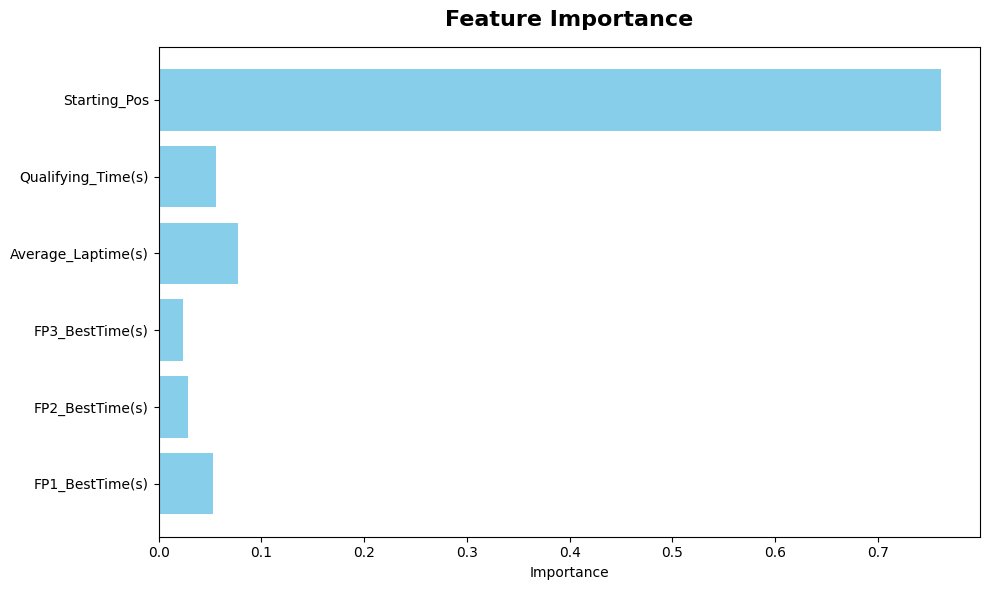

In [68]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))
plt.barh(features, feature_importance, color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importance", fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("Plots/Feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()